In [1]:
import matplotlib.pyplot as plt
import numpy as np

from link_prediction.config import (
    RESULTS_DIR,
)
from link_prediction.sensitivity import (
    run_parameter_sensitivity,
)

In [2]:
benchmark_name = "standard"

figure_directory = (
    RESULTS_DIR
    / "figures"
    / benchmark_name
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

(
    fold_metrics,
    network_summary,
    overall_summary,
) = run_parameter_sensitivity(
    benchmark_name=
        benchmark_name,
)

parameter sensitivity: 40 tasks, 6 workers


In [3]:
overall_summary[
    [
        "method_id",
        "method",
        "parameter",
        "parameter_value",
        "is_primary",
        "network_count",
        "average_precision_mean",
        "average_precision_sd_across_networks",
        "roc_auc_mean",
        "roc_auc_sd_across_networks",
    ]
].sort_values(
    [
        "method_id",
        "parameter_value",
    ]
).reset_index(
    drop=True
)

,method_id,method,parameter,parameter_value,is_primary,network_count,average_precision_mean,average_precision_sd_across_networks,roc_auc_mean,roc_auc_sd_across_networks
0,lit,LIT-i2,iterations,2.000,True,8,0.842047,0.160654,0.842387,0.160986
1,lit,LIT-i4,iterations,4.000,False,8,0.840864,0.159672,0.841202,0.160003
2,lit,LIT-i6,iterations,6.000,False,8,0.840471,0.159342,0.840810,0.159670
3,lpi,LPI-beta-0.001,beta,0.001,True,8,0.918001,0.081756,0.919203,0.081949
4,lpi,LPI-beta-0.01,beta,0.010,False,8,0.915975,0.080944,0.917672,0.081276
5,lpi,LPI-beta-0.1,beta,0.100,False,8,0.910095,0.079287,0.912625,0.079553
6,lrw,LRW-l3,steps,3.000,True,8,0.884737,0.118542,0.886278,0.117043
7,lrw,LRW-l5,steps,5.000,False,8,0.918139,0.072386,0.920884,0.069543
8,lrw,LRW-l7,steps,7.000,False,8,0.929402,0.056073,0.932938,0.050572
9,ora_cni,ORA-CNI-beta-0.001,beta,0.001,True,8,0.912332,0.079684,0.914384,0.080160


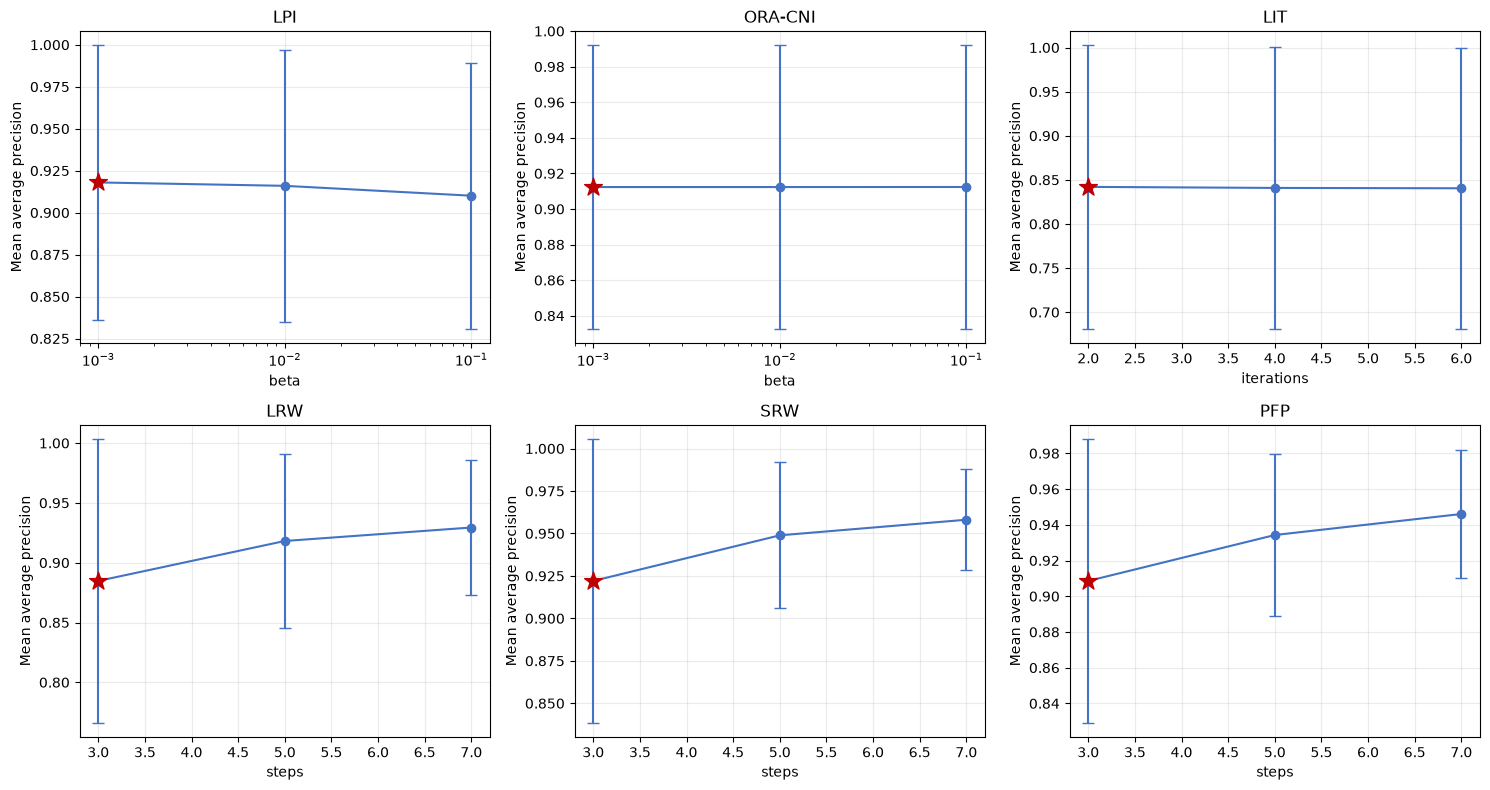

In [4]:
method_ids = [
    "lpi",
    "ora_cni",
    "lit",
    "lrw",
    "srw",
    "pfp",
]

figure, axes = plt.subplots(
    2,
    3,
    figsize=(
        15,
        8,
    ),
)

for method_id, axis in zip(
    method_ids,
    axes.ravel(),
    strict=True,
):
    method_summary = (
        overall_summary[
            overall_summary[
                "method_id"
            ]
            == method_id
        ]
        .sort_values(
            "parameter_value"
        )
    )

    axis.errorbar(
        method_summary[
            "parameter_value"
        ],
        method_summary[
            "average_precision_mean"
        ],
        yerr=method_summary[
            "average_precision_sd_across_networks"
        ],
        marker="o",
        capsize=4,
        color="#4472C4",
    )

    primary = method_summary[
        method_summary[
            "is_primary"
        ]
    ]

    axis.scatter(
        primary[
            "parameter_value"
        ],
        primary[
            "average_precision_mean"
        ],
        marker="*",
        s=180,
        color="#C00000",
        zorder=3,
    )

    parameter = method_summary[
        "parameter"
    ].iloc[0]

    if parameter == "beta":
        axis.set_xscale(
            "log"
        )

    axis.set_title(
        method_id.upper().replace(
            "_",
            "-",
        )
    )

    axis.set_xlabel(
        parameter
    )

    axis.set_ylabel(
        "Mean average precision"
    )

    axis.grid(
        alpha=0.25,
    )

figure.tight_layout()

figure.savefig(
    figure_directory
    / "parameter_sensitivity_average_precision.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "parameter_sensitivity_average_precision.pdf",
    bbox_inches="tight",
)

plt.show()

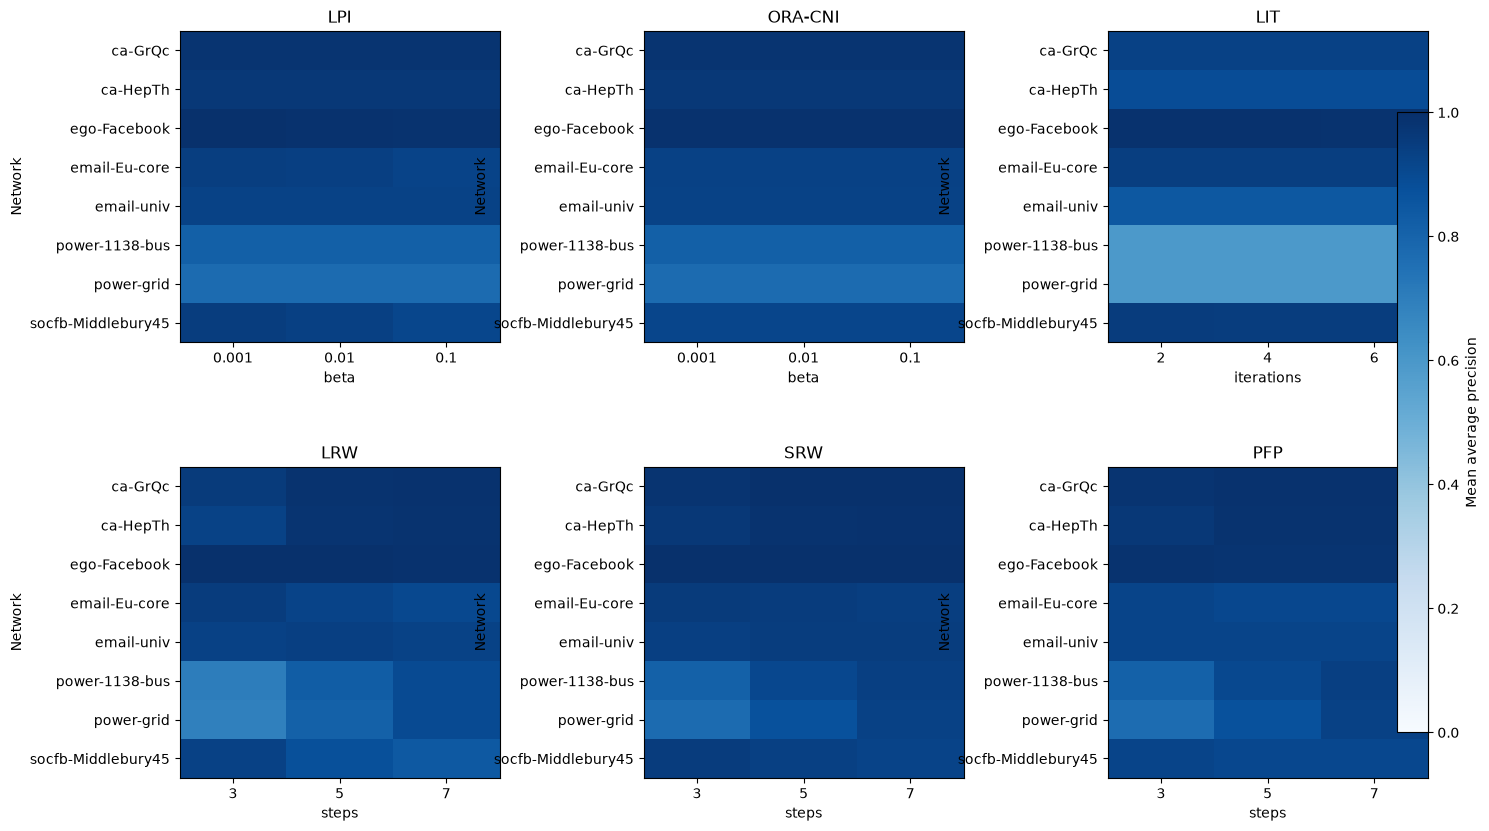

In [5]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(
        16,
        9,
    ),
)

for method_id, axis in zip(
    method_ids,
    axes.ravel(),
    strict=True,
):
    method_summary = (
        network_summary[
            network_summary[
                "method_id"
            ]
            == method_id
        ]
    )

    matrix = (
        method_summary
        .pivot(
            index="network",
            columns="parameter_value",
            values="average_precision_mean",
        )
        .sort_index(
            axis=0
        )
        .sort_index(
            axis=1
        )
    )

    image = axis.imshow(
        matrix.to_numpy(),
        aspect="auto",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
    )

    axis.set_xticks(
        range(
            len(
                matrix.columns
            )
        )
    )

    axis.set_xticklabels(
        [
            f"{value:g}"
            for value
            in matrix.columns
        ]
    )

    axis.set_yticks(
        range(
            len(
                matrix.index
            )
        )
    )

    axis.set_yticklabels(
        matrix.index
    )

    axis.set_title(
        method_id.upper().replace(
            "_",
            "-",
        )
    )

    axis.set_xlabel(
        method_summary[
            "parameter"
        ].iloc[0]
    )

    axis.set_ylabel(
        "Network"
    )

figure.colorbar(
    image,
    ax=axes.ravel().tolist(),
    label="Mean average precision",
    fraction=0.025,
    pad=0.02,
)

figure.subplots_adjust(
    left=0.12,
    right=0.9,
    bottom=0.1,
    top=0.93,
    wspace=0.45,
    hspace=0.4,
)

figure.savefig(
    figure_directory
    / "network_parameter_sensitivity_heatmaps.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "network_parameter_sensitivity_heatmaps.pdf",
    bbox_inches="tight",
)

plt.show()

In [6]:
network_summary[
    [
        "network",
        "domain",
        "method_id",
        "method",
        "parameter",
        "parameter_value",
        "is_primary",
        "average_precision_mean",
        "average_precision_std",
        "roc_auc_mean",
        "roc_auc_std",
    ]
].sort_values(
    [
        "method_id",
        "network",
        "parameter_value",
    ]
).reset_index(
    drop=True
)

,network,domain,method_id,method,parameter,parameter_value,is_primary,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std
0,ca-GrQc,scientific_collaboration,lit,LIT-i2,iterations,2.0,True,0.933174,0.006675,0.932981,0.006748
1,ca-GrQc,scientific_collaboration,lit,LIT-i4,iterations,4.0,False,0.932904,0.006802,0.932798,0.006830
2,ca-GrQc,scientific_collaboration,lit,LIT-i6,iterations,6.0,False,0.932780,0.006886,0.932708,0.006893
3,ca-HepTh,scientific_collaboration,lit,LIT-i2,iterations,2.0,True,0.887772,0.003209,0.887774,0.003159
4,ca-HepTh,scientific_collaboration,lit,LIT-i4,iterations,4.0,False,0.887651,0.003236,0.887707,0.003169
...,...,...,...,...,...,...,...,...,...,...,...
139,power-grid,infrastructure,srw,SRW-l5,steps,5.0,False,0.873778,0.009779,0.874011,0.009293
140,power-grid,infrastructure,srw,SRW-l7,steps,7.0,False,0.932399,0.008453,0.932984,0.008247
141,socfb-Middlebury45,social,srw,SRW-l3,steps,3.0,True,0.951415,0.000979,0.955407,0.000937
142,socfb-Middlebury45,social,srw,SRW-l5,steps,5.0,False,0.936898,0.000974,0.943281,0.000889
